# Introducción a la Estadistica : Estadistica Descriptiva
---

### Cargando Librerías
---

In [60]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as ss
from scipy.stats import norm, variation, kurtosis, skew


### Utiizamos en dataset :  "acarreo" de una Mina Subterranea 
---

In [61]:
#Visualicemos de forma general la data que tenemos (5 primeras filas)
acarreo = pd.read_excel('BD_Extraccion.xlsx',sheet_name='datos', header=1)   # utilizamos la ubicacion fisica de archivo en la pc
acarreo.head(5)

,FECHA,TURNO,ZONA,TIPO_LABOR,NIVEL,CUERPO,LABOR,VOLQUETES,PLAN_SEMANAL,PLAN_DIARIO,ACARREO_DIARIO
0,2020-01-01,A,Zona Alta,Tajos,1910.0,OB6A,T-841B,NaN,2500.0,NaN,NaN
1,2020-01-01,A,Zona Alta,Tajos,1880.0,OB6A,T-731B,6.0,1000.0,2500.0,1575.0
2,2020-01-01,A,Zona Alta,Tajos,1880.0,OB6A,T-761E,5.0,2000.0,2500.0,2690.0
3,2020-01-01,A,Zona Baja,Tajos,1650.0,OB1,T-001E,8.0,2500.0,2600.0,2417.0
4,2020-01-01,A,Zona Baja,Tajos,1640.0,OB1,T-101,6.0,1500.0,2000.0,985.0


In [10]:
#Muestra los datos que faltan
acarreo.count()

FECHA             1149
TURNO             1149
ZONA              1149
TIPO_LABOR        1149
NIVEL             1144
CUERPO            1144
LABOR             1144
VOLQUETES          437
PLAN_SEMANAL       526
PLAN_DIARIO        551
ACARREO_DIARIO     990
dtype: int64

### Información de las variables
---

In [11]:
#visualicemos solo las columnas 
acarreo.columns

Index([&#39;FECHA&#39;, &#39;TURNO&#39;, &#39;ZONA&#39;, &#39;TIPO_LABOR&#39;, &#39;NIVEL&#39;, &#39;CUERPO&#39;, &#39;LABOR &#39;,
       &#39;VOLQUETES&#39;, &#39;PLAN_SEMANAL&#39;, &#39;PLAN_DIARIO&#39;, &#39;ACARREO_DIARIO&#39;],
      dtype=&#39;object&#39;)

In [12]:
#Descripcion del dataset de titanic
acarreo.info()

&lt;class &#39;pandas.core.frame.DataFrame&#39;&gt;
RangeIndex: 1149 entries, 0 to 1148
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   FECHA           1149 non-null   datetime64[ns]
 1   TURNO           1149 non-null   object        
 2   ZONA            1149 non-null   object        
 3   TIPO_LABOR      1149 non-null   object        
 4   NIVEL           1144 non-null   float64       
 5   CUERPO          1144 non-null   object        
 6   LABOR           1144 non-null   object        
 7   VOLQUETES       437 non-null    float64       
 8   PLAN_SEMANAL    526 non-null    float64       
 9   PLAN_DIARIO     551 non-null    float64       
 10  ACARREO_DIARIO  990 non-null    float64       
dtypes: datetime64[ns](1), float64(5), object(5)
memory usage: 98.9+ KB


In [13]:
#Caclula los la cantidad de valores null por columna
acarreo.isnull().sum()

FECHA               0
TURNO               0
ZONA                0
TIPO_LABOR          0
NIVEL               5
CUERPO              5
LABOR               5
VOLQUETES         712
PLAN_SEMANAL      623
PLAN_DIARIO       598
ACARREO_DIARIO    159
dtype: int64

### df1: datos de acerreo por dia
---

In [57]:
df1 = acarreo.groupby(['FECHA'])[('PLAN_DIARIO','ACARREO_DIARIO')].sum().reset_index(['FECHA'])
df1.head(3)

,FECHA,PLAN_DIARIO,ACARREO_DIARIO
0,2020-01-01,18000.0,15889.0
1,2020-01-02,18200.0,19411.0
2,2020-01-03,20700.0,18752.0


### Medidas de Posición
---
* Medidas de Tendencia Central : media, mediana, moda
* Medidas de Tendencia No Central : cuartiles, deciles, percentiles

In [127]:
#Media :Es el promedio de todos los valores en los datos
#Mediana : Es el valor que se encuentra en el centro del conjunto de datos

df1.describe()

,PLAN_DIARIO,ACARREO_DIARIO
count,60.000000,60.000000
mean,17383.333333,17812.650000
std,3010.218004,2409.943996
min,8500.000000,12271.000000
25%,16000.000000,16350.750000
50%,17900.000000,17960.000000
75%,19825.000000,19445.000000
max,21800.000000,22890.000000


### Quartiles y Deciles

---
#### Qk = Dividen al conjunto de datos en cuatro partes iguales
#### Dk = Los deciles son nueve valores (Dk; k = 1, 2, ..., 9) que dividen al conjunto de datos en diez partes iguales


In [49]:
#Q1 = pd.deci(df1['PLAN_DIARIO']).
print(df1.quantile([0,0.25,0.5,0.75,1]))

      PLAN_DIARIO  REALIZADO_DIARIO
0.00       8500.0          12271.00
0.25      16000.0          16350.75
0.50      17900.0          17960.00
0.75      19825.0          19445.00
1.00      21800.0          22890.00


In [77]:
# Percentile values in summary, include 10% and 90%
deciles = df1.describe(percentiles=[.1, .2, .25, .3, .4, .5, .6, .7, .75, .8, .9, 1])
#deciles = df1.groupby(pd.qcut(df1.PLAN_DIARIO, 10))
#df_deciles.head(3)
deciles

,PLAN_DIARIO,ACARREO_DIARIO
count,60.000000,60.000000
mean,17383.333333,17812.650000
std,3010.218004,2409.943996
min,8500.000000,12271.000000
10%,12980.000000,14795.000000
20%,14780.000000,15531.000000
25%,16000.000000,16350.750000
30%,16310.000000,16523.800000
40%,17120.000000,17309.800000
50%,17900.000000,17960.000000


### Histogramas

---

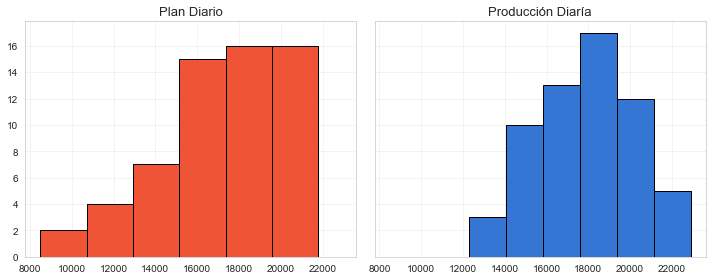

In [62]:
# Histogramas
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10,4), sharey=True, sharex=True)
#fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2)


ax0.hist(x = df1['PLAN_DIARIO'], bins = 6, histtype='bar', edgecolor='#000000', color='#EE5435')
ax0.set_title('Plan Diario', fontsize=13)
ax0.grid(linestyle=':', linewidth='0.5', color='grey', alpha=0.5)

ax1.hist(x = df1['ACARREO_DIARIO'], bins = 6, histtype='bar', edgecolor='#000000',color='#3575D3')
ax1.grid(linestyle=':', linewidth='0.5', color='grey', alpha=0.5)
ax1.set_title('Producción Diaría',fontsize=13)


fig.tight_layout()
plt.show()

### Grafico de Densisdades
---

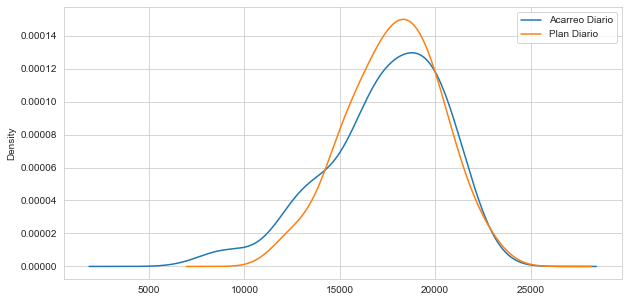

In [63]:
fig = plt.figure(figsize=(10,5))

df1.PLAN_DIARIO.plot(kind="kde")
df1.ACARREO_DIARIO.plot(kind="kde")
    
plt.legend({"Plan Diario", "Acarreo Diario"})
plt.show()

### Diagrama de Cajas : BoxPlot

---

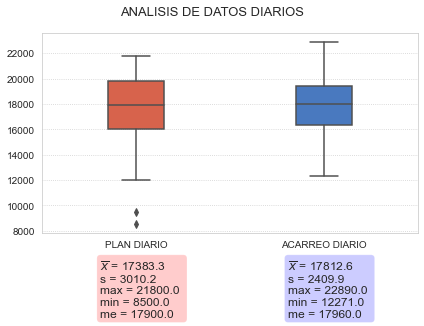

In [64]:
# Proposed themes: darkgrid, whitegrid, dark, white, and ticks
#sns.set(style='whitegrid')
sns.set_style("whitegrid", {'grid.linestyle': ':' } )
fig, axes = plt.subplots(1, 1, figsize=(6,5))
fig.suptitle('ANALISIS DE DATOS DIARIOS', fontsize=13)
my_colors = ["#EE5435", "#3575D3"]
sns.set_palette(my_colors)
g = sns.boxplot(data=df1, width=0.3)  

xvalues = ["PLAN DIARIO","ACARREO DIARIO"]
plt.xticks(np.arange(2), xvalues)
### Provide mean and standard deviation for each product ###


# Text p1
mean = round(df1['PLAN_DIARIO'].mean(),1)
sd = round(df1['PLAN_DIARIO'].std(),1)
ma = round(df1['PLAN_DIARIO'].max(),1)
mi = round(df1['PLAN_DIARIO'].min(),1)
me = round(df1['PLAN_DIARIO'].median(),1)

textstr = "$\overline {x}$" + f" = {mean} \ns = {sd} \nmax = {ma} \nmin = {mi} \nme = {me}"
props = dict(boxstyle='round', facecolor='r', alpha=0.2)
g.text(-0.19, 1200, textstr, fontsize=12, bbox=props)

# Text p2
mean = round(df1['ACARREO_DIARIO'].mean(),1)
sd = round(df1['ACARREO_DIARIO'].std(),1)
ma = round(df1['ACARREO_DIARIO'].max(),1)
mi = round(df1['ACARREO_DIARIO'].min(),1)
me = round(df1['ACARREO_DIARIO'].median(),1)

textstr = "$\overline {x}$" + f" = {mean} \ns = {sd} \nmax = {ma} \nmin = {mi} \nme = {me} "
props = dict(boxstyle='round', facecolor='b', alpha=0.2)
g.text(.81, 1200, textstr, fontsize=12, bbox=props)

plt.tight_layout()
plt.show()


Analisis datos diarios, graficos Boxplot: generamos dataframe df2df2

In [67]:
df2 = df.groupby(['FECHA','ZONA'])[('PLAN_DIARIO','ACARREO_DIARIO')].sum().reset_index(['FECHA','ZONA'])
df2.head(3)

,FECHA,ZONA,PLAN_DIARIO,ACARREO_DIARIO
0,2020-01-01,Zona Alta,10000.0,8477.0
1,2020-01-01,Zona Baja,8000.0,7412.0
2,2020-01-02,Zona Alta,7100.0,6918.0


### Diagrama de Cajas : BoxPlot desglosado por zonas

---

Text(0.5, 1.0, &#39;Acarreo Diario&#39;)

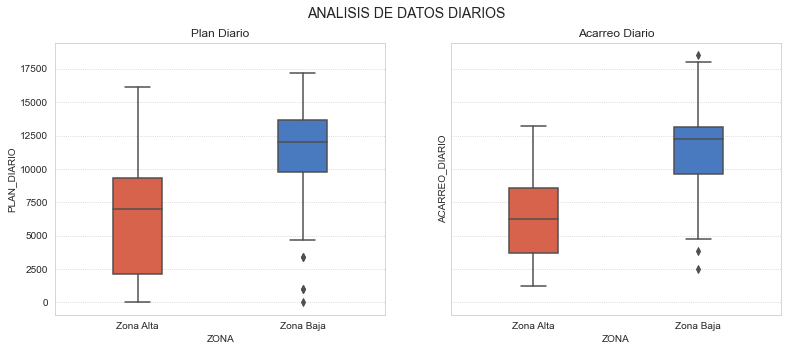

In [68]:
# Proposed themes: darkgrid, whitegrid, dark, white, and ticks
#sns.set(style='whitegrid')
sns.set_style("whitegrid", {'grid.linestyle': ':' })
fig, axes = plt.subplots(1, 2, figsize=(13,5), sharey=True)
fig.suptitle('ANALISIS DE DATOS DIARIOS', fontsize=14)
my_colors = ["#EE5435", "#3575D3"]
sns.set_palette(my_colors)
sns.boxplot( ax=axes[0], x=df2["ZONA"], y=df2["PLAN_DIARIO"], width=0.3).set_title('Plan Diario')  
sns.boxplot( ax=axes[1], x=df2["ZONA"], y=df2["ACARREO_DIARIO"], width=0.3).set_title('Acarreo Diario')


In [21]:
#Generamos Dataframe df2, Por Zona y Tipo Labor
df3 = df.groupby(['FECHA','TIPO_LABOR','ZONA'])[('PLAN_DIARIO','ACARREO_DIARIO')].sum().reset_index(['FECHA','TIPO_LABOR','ZONA'])
df3.head(3)


,FECHA,TIPO_LABOR,ZONA,PLAN_DIARIO,ACARREO_DIARIO
0,2020-01-01,Preparación,Zona Alta,0.0,533.0
1,2020-01-01,Preparación,Zona Baja,0.0,1021.0
2,2020-01-01,Tajos,Zona Alta,10000.0,7944.0


### Diagrama de Cajas : BoxPlot desglosado por Zonas y Tipo de Labor

---

Text(0.5, 1.0, 'Acarreo Diario')

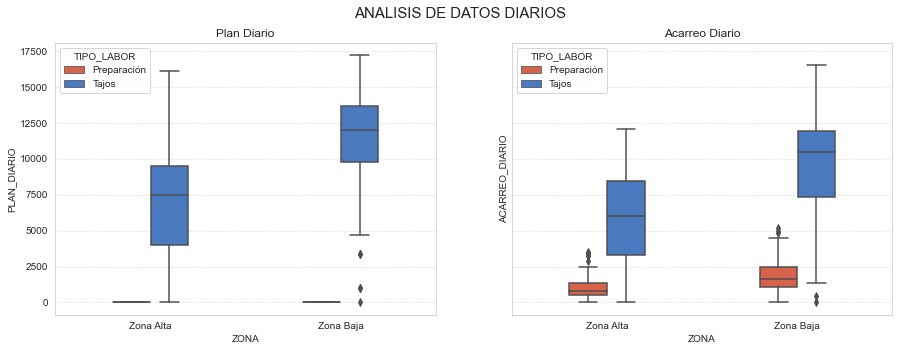

In [131]:
# Proposed themes: darkgrid, whitegrid, dark, white, and ticks
sns.set_style("whitegrid", {'grid.linestyle': ':' })
fig, axes = plt.subplots(1, 2, figsize=(15,5), sharey=True)
fig.suptitle('ANALISIS DE DATOS DIARIOS', fontsize=15)
my_colors = ["#EE5435", "#3575D3"]
sns.set_palette(my_colors)
sns.boxplot( ax=axes[0], x=df3["ZONA"], y=df3["PLAN_DIARIO"], hue=df3["TIPO_LABOR"], width=0.4).set_title('Plan Diario')  
sns.boxplot( ax=axes[1], x=df3["ZONA"], y=df3["ACARREO_DIARIO"], hue=df3["TIPO_LABOR"], width=0.4).set_title('Acarreo Diario')

### Medidas de Dispersión : Rango (R) y Rango Intercuartilico (RI)

---

In [82]:
# Rango (R) 
# Es una medida de variabilidad que se obtiene de la diferencia entre el máximo y mínimo valor de la variable.

range_Plan = df1['PLAN_DIARIO'].max() - df1['PLAN_DIARIO'].min()
print(" Rango (Plan Diario) :", range_Plan)

range_Acarreo = df1['ACARREO_DIARIO'].max() - df1['ACARREO_DIARIO'].min()
print(" Rango (Acarreo Diario) :",range_Acarreo)


 Rango (Plan Diario) : 13300.0
 Rango (Acarreo Diario) : 10619.0


In [80]:
# Rango Intercuartilico (RI)
# Se define como la diferencia entre los cuartiles tres (Q3) y uno (Q1); Cálculo: Rango Intercuartílico (RI) es el rango en el que se encuentra el 50% central de los datos.
# utilizamos la libreria scipy.stats.iqr

# Calculate Interquartile Range (IQR), 75% - 25%
IQR_Plan = ss.iqr(df1['PLAN_DIARIO'])
print(" Rango Intercuartílico (Plan Diario) :", IQR_Plan)

IQR_Acarreo = ss.iqr(df1['ACARREO_DIARIO'])
print(" Rango Intercuartílico (Acarreo Diario) :",IQR_Acarreo)


 Rango Intercuartílico (Plan Diario) : 3825.0
 Rango Intercuartílico (Acarreo Diario) : 3094.25


### Varianza y Desviacion Estandar 

---

In [153]:
# Varianza : Mide la variabilidad del conjunto de datos con respecto a la media
# Desviación Estándar La desviación estándar mide la desviación media o promedio de cada dato con respecto a la media

std = df1['PLAN_DIARIO'].std(ddof=1)
print ("Desviacion Estandar :", std.round(1))

var = df1['PLAN_DIARIO'].var(ddof=1)
print ("Varianza :", var.round(1))


Desviacion Estandar : 3010.2
Varianza : 9061412.4


### Coeficiente de Variación

---

In [113]:
# El coeficiente de variación : es una medida que sirve para comparar entre dos muestras, cuál varía más y cuál es más estable. Es una simple división, de la desviación típica sobre la media, sin embargo, SciPy nos ofrece una función ya preparada.
# Indica la proporción que representa la desviación estándar con respecto a la media en el conjunto de datos

coef_var = ss.variation(df1['PLAN_DIARIO'])
print("Coeficiente de Variación (Plan Diario) : ", round(coef_var,2))

coef_var = ss.variation(df1['ACARREO_DIARIO'])
print("Coeficiente de Variación (Acarreo) : ", round(coef_var,2))

Coeficiente de Variación (Plan Diario) :  0.17
Coeficiente de Variación (Acarreo) :  0.13


### Medidas de Asimetría

---
#### Estas medidas brindan información sobre la dirección horizontal que toma la distribución de los datos con respecto a su centro.


In [84]:
#Medidas Asimetricas : para saber si los datos estan repartidos de forma simétrica vamos a usar la función "skew" de SciPy.
#Si Ak < 0 tiene Asimetria negativa, Ak = 0 Distribucion simetrica, Ak > 0 Distribucion con Asimetria Positiva 

asimetria_Plan = skew(df1['PLAN_DIARIO'])
print("Valor de Asimetria (Plan diario): ", asimetria_Plan)

asimetria_Acarreo = skew(df1['ACARREO_DIARIO'])
print("Valor de Asimetria (Acarreo Diario):", asimetria_Acarreo)

Valor de Asimetria (Plan diario):  -0.8268646067327561
Valor de Asimetria (Acarreo Diario): -0.21791089209262168


In [30]:
#alternativa
df1.skew()

PLAN_DIARIO      -0.848219
ACARREO_DIARIO   -0.223539
dtype: float64

### Medidas de Curtosis

---
#### Estas medidas brindan información sobre la deformación vertical de una distribución de frecuencias en comparación con la curva normal
Ku > 0.263 (Distribución Leptocúrtica ) | Ku = 0.263 (Distribución Mesocúrtica ) | Ku <0.263 (Distribución Platicúrtica )

In [85]:

Kurtosis_Plan = kurtosis(df1['PLAN_DIARIO'])
print("Curtosis (Plan Diario): ",Kurtosis_Plan)

Kurtosis_Acarreo = kurtosis(df1['ACARREO_DIARIO'])
print("Curtosis (Acarreo): ",Kurtosis_Acarreo)

Curtosis (Plan Diario):  0.3138927285584079
Curtosis (Acarreo):  -0.3454271147090018


In [29]:
#alternativa
df1.kurt()

PLAN_DIARIO       0.448790
ACARREO_DIARIO   -0.268963
dtype: float64

### Covarianza y Correlacion de Pearson

---

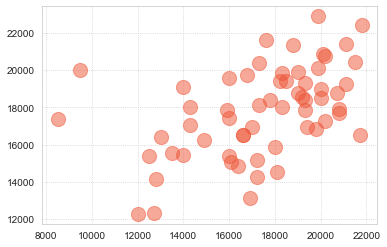

In [106]:
#Diagramas de dispersion
plt.scatter(df1['PLAN_DIARIO'], df1['ACARREO_DIARIO'], s=200,alpha=0.5)
plt.show()

&lt;seaborn.axisgrid.FacetGrid at 0x7fa528eec590&gt;

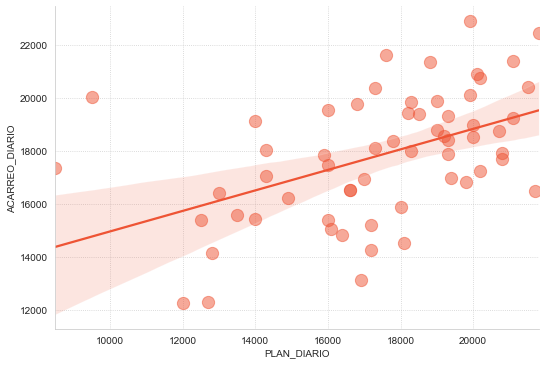

In [104]:
#La gráfica incluye además de los datos incluye la regresión lineal y el intervalo de confianza
from seaborn import lmplot
lmplot('PLAN_DIARIO', 'ACARREO_DIARIO', data=df1,aspect=1.5, scatter_kws={"s": 150, "alpha": 0.5})

In [71]:
# Covarianza
# Si Cov(x,y) > 0, hay dependencia directa (positiva), es decir a grandes valores de X corresponden grandes valores de Y.
# Si Cov(x,y) = 0, Una covarianza (0) se interpreta como la no existencia de una relación lineal entre las dos variables estudiadas.
#Si Cov(x,y) < 0, hay dependencia inversa o negativa es decir, a grandes valores de X corresponden pequeños valores de Y

cov_mat = df1.cov()
cov_mat

,PLAN_DIARIO,ACARREO_DIARIO
PLAN_DIARIO,9.061412e+06,3.507228e+06
ACARREO_DIARIO,3.507228e+06,5.807830e+06


In [72]:
cov_mat.loc["PLAN_DIARIO", "ACARREO_DIARIO"]

3507227.9661016944

In [73]:
# Coeficiente de correlacion
# R ≅ −1: La relación entre las variables es perfecta e inversa.
# R ≅ 0: No existe relación entre las variables
# R ≅ 1: La relación entre las variables es perfecta y directa.

corr_mat = df1.corr()
corr_mat

,PLAN_DIARIO,ACARREO_DIARIO
PLAN_DIARIO,1.000000,0.483458
ACARREO_DIARIO,0.483458,1.000000


In [74]:
corr_mat.loc["PLAN_DIARIO", "ACARREO_DIARIO"]

0.4834583844413982

### Graficos de Distribución de datos
---

&lt;seaborn.axisgrid.PairGrid at 0x7fa525715110&gt;

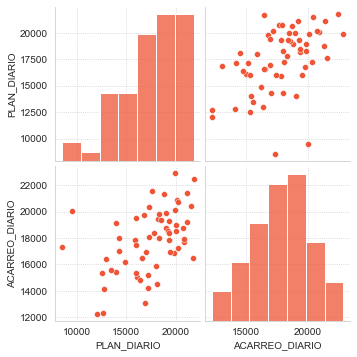

In [75]:
sns.pairplot(df1)

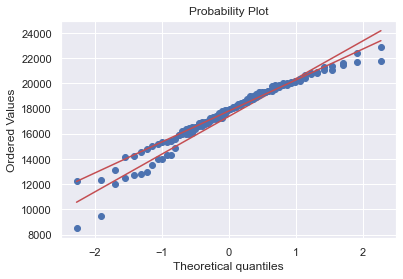

In [109]:
import pylab
ss.probplot(df1['PLAN_DIARIO'], dist="norm",plot=pylab)
ss.probplot(df1['ACARREO_DIARIO'], dist="norm",plot=pylab)
pylab.show()